PCA model saved successfully.


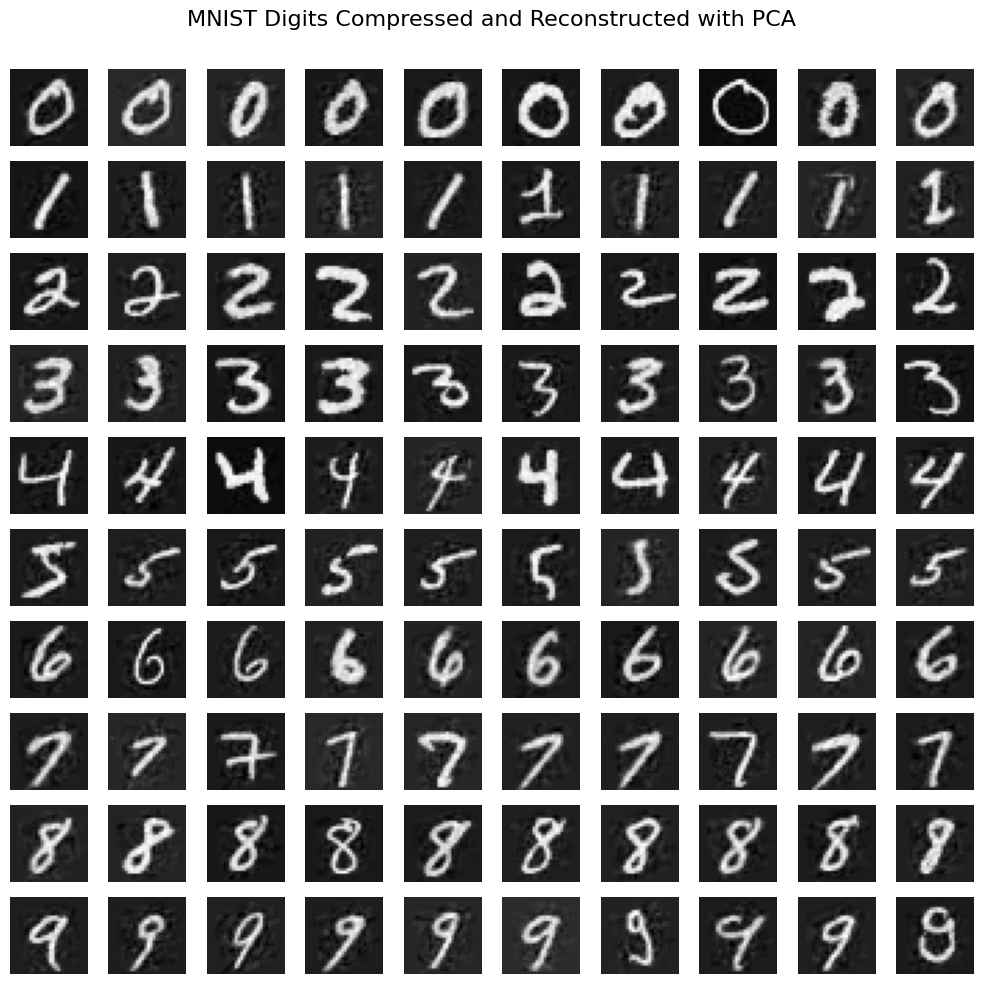

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from sklearn.decomposition import PCA
import pickle

# MNIST 데이터셋 로드
transform = transforms.Compose([transforms.ToTensor()])
mnist_data = MNIST(root='./data', train=True, transform=transform, download=True)

# 숫자별로 10개씩 추출
num_samples = 10
sampled_images = {i: [] for i in range(10)}  # 숫자별로 이미지 저장

for img, label in mnist_data:
    if len(sampled_images[label]) < num_samples:
        sampled_images[label].append(img.squeeze().numpy().flatten())  # 1D 벡터로 변환
    if all(len(images) == num_samples for images in sampled_images.values()):
        break

# 숫자별로 10개씩 추출한 이미지를 리스트로 결합하여 PCA에 입력
data = []
labels = []
for label, images in sampled_images.items():
    data.extend(images)
    labels.extend([label] * num_samples)
data = np.array(data)

# PCA 적용 (차원 축소 및 복원)
latent_dim = 64  # 원하는 차원 수
pca = PCA(n_components=latent_dim)
compressed_data = pca.fit_transform(data)
reconstructed_data = pca.inverse_transform(compressed_data)
reconstructed_data = reconstructed_data.reshape(-1, 28, 28)  # 2D 이미지 형태로 복원

# PCA 모델 저장
with open(f'savepoints/pca_{latent_dim}.pkl', 'wb') as file:
    pickle.dump(pca, file)
print("PCA model saved successfully.")

# 10x10 그리드에 복원된 이미지 시각화
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
fig.suptitle('MNIST Digits Compressed and Reconstructed with PCA', fontsize=16)

for i in range(10):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(reconstructed_data[idx], cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Adjust top to prevent overlap with suptitle
plt.show()


In [1]:
# 랜덤 잠재 벡터 생성 및 복원
random_latent_vectors = np.random.normal(0, 1, (100, latent_dim))  # 평균 0, 표준편차 1의 랜덤 벡터
reconstructed_images = pca.inverse_transform(random_latent_vectors)
reconstructed_images = reconstructed_images.reshape(-1, 28, 28)  # 2D 이미지 형태로 변환

# 10x10 그리드에 복원된 이미지 시각화
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
fig.suptitle('Random Latent Vectors Reconstructed with PCA', fontsize=16)

for i in range(10):
    for j in range(10):
        idx = i * 10 + j
        axes[i, j].imshow(reconstructed_images[idx], cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Adjust top to prevent overlap with suptitle
plt.show()

NameError: name 'np' is not defined

In [3]:
import random
# 클래스별로 2000개의 이미지를 랜덤하게 추출하여 저장할 딕셔너리 초기화
num_images_per_class = 2000
data_dict = {}

for digit in range(10):
    # 해당 클래스의 이미지 필터링
    images_for_class = [img for img, label in mnist_data if label == digit]
    print("Number of images for digit", digit, ":", len(images_for_class))
    
    # 랜덤하게 2000개의 이미지 선택
    selected_images = random.sample(images_for_class, num_images_per_class)
    
    # 원본 이미지와 latent 값 저장할 리스트
    original_images = []
    latent_vectors = []
    
    # 각 이미지를 처리하여 원본 이미지와 latent 값 추출
    for img in selected_images:
        img_np = img.numpy().flatten()  # 1D 벡터로 변환
        original_images.append(img.numpy())  # 원본 이미지 저장
        
        # PCA를 통해 latent 벡터 추출
        latent_vector = pca.transform([img_np])[0]  # (latent_dim,)
        latent_vectors.append(latent_vector)

    # numpy 배열로 변환
    original_images = np.array(original_images).squeeze()  # (2000, 28, 28)
    latent_vectors = np.array(latent_vectors).squeeze()    # (2000, latent_dim)
    print(latent_vectors.shape, latent_vectors.max(), latent_vectors.min())
    
    # data_dict에 저장
    data_dict[f'{digit}_raw'] = original_images
    data_dict[f'{digit}_latent'] = latent_vectors

np.savez(f'./data/MNIST/mnist_{latent_dim}_pca_{num_images_per_class}.npz', **data_dict)


Number of images for digit 0 : 5923
(2000, 64) 8.329880941358784 -5.086253300967739
Number of images for digit 1 : 6742
(2000, 64) 4.18101228765598 -4.00538894855013
Number of images for digit 2 : 5958
(2000, 64) 5.759575269644277 -4.7341119711019495
Number of images for digit 3 : 6131
(2000, 64) 5.680279189717988 -4.51755143439844
Number of images for digit 4 : 5842
(2000, 64) 4.683822473395127 -5.494824370007531
Number of images for digit 5 : 5421
(2000, 64) 5.975807631672064 -4.290533920913365
Number of images for digit 6 : 5918
(2000, 64) 5.351789952416339 -5.617625158971794
Number of images for digit 7 : 6265
(2000, 64) 4.741591534723036 -5.091948202118516
Number of images for digit 8 : 5851
(2000, 64) 6.198441470979427 -4.4206414657157795
Number of images for digit 9 : 5949
(2000, 64) 5.031378254146501 -4.710192217044179
